# This notebook has some utilities to manage the already deployed cluster. 
- trigger VFL

## FABlib API References Examples

- [fablib.show_config](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.show_config)
- [fablib.list_sites](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_sites)
- [fablib.list_hosts](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.list_hosts)
- [fablib.new_slice](https://fabric-fablib.readthedocs.io/en/latest/fablib.html#fabrictestbed_extensions.fablib.fablib.FablibManager.new_slice)
- [slice.add_node](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.add_node)
- [slice.submit](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.submit)
- [slice.get_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.get_nodes)
- [slice.list_nodes](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.list_nodesß)
- [slice.show](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.show)
- [node.execute](https://fabric-fablib.readthedocs.io/en/latest/node.html#fabrictestbed_extensions.fablib.node.Node.execute)
- [slice.delete](https://fabric-fablib.readthedocs.io/en/latest/slice.html#fabrictestbed_extensions.fablib.slice.Slice.delete) 

In [7]:
%%time
import datetime
import json
import asyncio
from configuration import SLICE_NAME
from utils import upload_and_execute_file, upload_file, execute_file

from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager

fablib = fablib_manager()

fablib.show_config();

User: apipilikas@gmail.com bastion key is valid!
Configuration is valid


Orchestrator,orchestrator.fabric-testbed.net
Credential Manager,cm.fabric-testbed.net
Core API,uis.fabric-testbed.net
Artifact Manager,artifacts.fabric-testbed.net
Token File,/home/fabric/.tokens.json
Project ID,49f65ad7-d8a2-4ab9-8ca0-ba777a2e0ea2
Bastion Host,bastion.fabric-testbed.net
Bastion Username,apipilikas_0000444352
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Slice Private Key File,/home/fabric/work/fabric_config/slice_key


CPU times: user 62.3 ms, sys: 21.1 ms, total: 83.4 ms
Wall time: 3.14 s


In [ ]:
slice = fablib.get_slice(name=SLICE_NAME);
nodes = slice.get_nodes();
# fablib.list_sites();


In [ ]:
# Print ssh information
try:
    # Get slice nodes
    for node in slice.get_nodes():
        print(f"Node: {node.get_name()}")
        # Get the original SSH command
        original_ssh_command = node.get_ssh_command()
        # Print SSH commands to get into the nodes
        print(f"  SSH Command from FABRIC: {original_ssh_command}")
        # Replace the file paths in the SSH command
        updated_ssh_command = original_ssh_command.replace(
            "/home/fabric/work/fabric_config/slice_key", "C:/Users/apipi/.ssh/slice_key"
        ).replace(
            "/home/fabric/work/fabric_config/ssh_config", "C:/Users/apipi/.ssh/fabric_ssh_config"
        )
        # Print the updated SSH command
        print(f"  SSH Command locally : {updated_ssh_command}")
    
except Exception as e:
    print(f"Fail: {e}")
    traceback.print_exc()

In [ ]:
# get nodes and IPs 
def get_ip(node):
    interface = node.get_interface(network_name=f"Network-{node.get_site()}")
    return interface.get_ip_addr()

nodes_dict= dict()

for node in nodes[:]:
    ip = get_ip(node)
    name = node.get_name()
    nodes_dict[name] = {"ip": ip, "node": node}
    print(f"{name}: {ip}")

# print(nodes_dict)

In [ ]:
main_node=nodes_dict['control']['node']
print(f"The main node for now on is [{main_node.get_name()}]")

In [34]:
# This is for resetting the kubespray cluster. 
# Use this if you are troubleshooting your Kubernetes cluster
# and you want to redeploy fresh.

# nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/reset_kubespray.sh", remote_file_path="reset.sh");
# nodes_dict['control']['node'].execute(f"chmod +x reset.sh && ./reset.sh");

In [35]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time

def plot_accuracy(rounds, accuracies, clients, window=5, show_smoothed=True):
    clear_output(wait=True)
    # Plot accuracy over rounds, color by number of clients
    plt.figure(figsize=(10, 6))

    # Find transition points where number of clients changes
    # We'll split into segments with constant number of clients
    segments = []
    start_idx = 0
    for i in range(1, len(clients)):
        if clients[i] != clients[i - 1]:
            segments.append((start_idx, i, clients[i - 1]))
            start_idx = i
    segments.append((start_idx, len(clients), clients[-1]))

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for idx, (start, end, n_clients) in enumerate(segments):
        plt.plot(rounds[start:end], accuracies[start:end], label=f"{n_clients} clients",
                 color=colors[idx % len(colors)])

    plt.xlabel('Training Round')
    plt.ylabel('r2 score')
    plt.title('VFL Training r2 score over training cycles')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.ylim(bottom=0, top=.8)
    plt.show()
        # time.sleep(1)

In [36]:
# import numpy as np
# from IPython.display import clear_output
# import matplotlib.pyplot as plt


# def moving_average_centered(x, w):
#     """Centered moving average (previous behavior) using numpy.convolve with mode='same'."""
#     if w <= 1:
#         return np.array(x, dtype=float)
#     kernel = np.ones(w, dtype=float) / w
#     return np.convolve(x, kernel, mode='same')


# def moving_average_causal(x, w):
#     """
#     Causal (past-only) moving average:
#     For each index i, average over x[max(0, i-w+1) : i+1].
#     This returns an array of the same length as x where each value
#     only depends on the current and previous values.
#     """
#     x = np.asarray(x, dtype=float)
#     n = x.shape[0]
#     if w <= 1 or n == 0:
#         return x.copy()

#     cumsum = np.cumsum(x)  # cumsum[i] = sum(x[0..i])
#     out = np.empty_like(x)
#     for i in range(n):
#         start = i - w + 1
#         if start <= 0:
#             out[i] = cumsum[i] / (i + 1)
#         else:
#             out[i] = (cumsum[i] - cumsum[start - 1]) / w
#     return out


# def plot_accuracy(rounds, accuracies, clients, window=5, show_smoothed=True, mode="causal"):
#     """
#     Plot r2 score over rounds with optional smoothing.

#     Parameters:
#     - rounds: list/array of x values
#     - accuracies: list/array of y values
#     - clients: list/array of client counts (used to segment where client count changes)
#     - window: integer smoothing window size (default 5)
#     - show_smoothed: if True, plot the smoothed curve as a dashed line and raw faintly;
#                      if False, plot only the smoothed curve.
#     - mode: "causal" (use only past values for the moving average) or "center" (centered window).
#     """
#     clear_output(wait=True)
#     plt.figure(figsize=(10, 6))

#     rounds = np.asarray(rounds)
#     accuracies = np.asarray(accuracies, dtype=float)
#     clients = np.asarray(clients)

#     # Find transition points where number of clients changes
#     segments = []
#     start_idx = 0
#     for i in range(1, len(clients)):
#         if clients[i] != clients[i - 1]:
#             segments.append((start_idx, i, clients[i - 1]))
#             start_idx = i
#     segments.append((start_idx, len(clients), clients[-1]))

#     colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

#     for idx, (start, end, n_clients) in enumerate(segments):
#         seg_rounds = rounds[start:end]
#         seg_acc = accuracies[start:end]
#         color = colors[idx % len(colors)]

#         seg_len = len(seg_acc)
#         eff_w = max(1, min(window, seg_len))

#         if mode == "causal":
#             smoothed = moving_average_causal(seg_acc, eff_w)
#         elif mode == "center":
#             smoothed = moving_average_centered(seg_acc, eff_w)
#         else:
#             raise ValueError("mode must be 'causal' or 'center'")

#         if show_smoothed:
#             # plot raw faintly and smoothed prominently
#             plt.plot(seg_rounds, seg_acc, label=f"{n_clients} clients (raw)" if idx == 0 else None,
#                      color=color, alpha=0.25, linewidth=1)
#             plt.plot(seg_rounds, smoothed, label=f"{n_clients} clients (smoothed)",
#                      color=color, linestyle='--', linewidth=2)
#         else:
#             # plot only smoothed (replace raw)
#             plt.plot(seg_rounds, smoothed, label=f"{n_clients} clients",
#                      color=color, linewidth=2)

#     plt.xlabel('Training Round')
#     plt.ylabel('r2 score')
#     plt.title('VFL Training r2 score over training cycles')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     # keep these limits if you want; adjust as needed for negative scores
#     plt.ylim(bottom=0, top=0.9)
#     plt.show()

In [7]:
# import numpy as np
# from IPython.display import clear_output
# import matplotlib.pyplot as plt


# def moving_average_causal(x, w):
#     x = np.asarray(x, dtype=float)
#     n = x.shape[0]
#     if w <= 1 or n == 0:
#         return x.copy()
#     cumsum = np.cumsum(x)
#     out = np.empty_like(x)
#     for i in range(n):
#         start = i - w + 1
#         if start <= 0:
#             out[i] = cumsum[i] / (i + 1)
#         else:
#             out[i] = (cumsum[i] - cumsum[start - 1]) / w
#     return out


# def plot_accuracy(
#     rounds,
#     accuracies,
#     clients,
#     window=5,
#     show_smoothed=True,
#     mode="causal",
#     min_display=0.0,
#     clip_marker_props=None,
# ):
#     """
#     Plot r2 score over rounds with smoothing and explicit clipping indicators.

#     Parameters:
#     - rounds, accuracies, clients: same as before
#     - window: smoothing window for causal moving average
#     - show_smoothed: if True show smoothed curve (dashed) and raw faintly
#     - mode: "causal" (past-only) or "center" (not used here)
#     - min_display: minimum y-value to display; values < min_display are clipped for plotting
#     - clip_marker_props: dict for customizing clipped-point marker (color, marker, size)
#     """
#     clear_output(wait=True)
#     plt.figure(figsize=(10, 6))

#     rounds = np.asarray(rounds)
#     accuracies = np.asarray(accuracies, dtype=float)
#     clients = np.asarray(clients)

#     if clip_marker_props is None:
#         clip_marker_props = {"color": "red", "marker": "v", "s": 80, "zorder": 5}

#     # Find transition points where number of clients changes
#     segments = []
#     start_idx = 0
#     for i in range(1, len(clients)):
#         if clients[i] != clients[i - 1]:
#             segments.append((start_idx, i, clients[i - 1]))
#             start_idx = i
#     segments.append((start_idx, len(clients), clients[-1]))

#     colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

#     total_clipped = 0
#     clipped_legend_shown = False

#     for idx, (start, end, n_clients) in enumerate(segments):
#         seg_rounds = rounds[start:end]
#         seg_acc = accuracies[start:end]
#         color = colors[idx % len(colors)]
#         seg_len = len(seg_acc)
#         eff_w = max(1, min(window, seg_len))

#         if mode == "causal":
#             smoothed = moving_average_causal(seg_acc, eff_w)
#         else:
#             # fallback: no smoothing
#             smoothed = seg_acc.copy()

#         # Where values are below display threshold
#         clipped_mask = seg_acc < min_display
#         n_clipped_seg = int(np.count_nonzero(clipped_mask))
#         total_clipped += n_clipped_seg

#         # Values to plot (clip them for display)
#         plot_raw = seg_acc.copy()
#         plot_raw[clipped_mask] = min_display

#         plot_smooth = smoothed.copy()
#         plot_smooth[plot_smooth < min_display] = min_display

#         # Plot raw faintly and smoothed prominently (or only smoothed if desired)
#         if show_smoothed:
#             plt.plot(
#                 seg_rounds,
#                 plot_raw,
#                 color=color,
#                 alpha=0.25,
#                 linewidth=1,
#                 label=f"{n_clients} clients (raw)" if idx == 0 else None,
#             )
#             plt.plot(
#                 seg_rounds,
#                 plot_smooth,
#                 color=color,
#                 linestyle="--",
#                 linewidth=2,
#                 label=f"{n_clients} clients (smoothed)",
#             )
#         else:
#             plt.plot(seg_rounds, plot_smooth, color=color, linewidth=2, label=f"{n_clients} clients")

#         # Mark clipped points with a downward marker at min_display
#         if n_clipped_seg > 0:
#             clipped_x = seg_rounds[clipped_mask]
#             clipped_y = np.full_like(clipped_x, fill_value=min_display, dtype=float)
#             # scatter wants x,y vectors; use marker props
#             plt.scatter(clipped_x, clipped_y, **clip_marker_props)
#             # Show one legend entry for clipped points
#             if not clipped_legend_shown:
#                 plt.scatter([], [], **clip_marker_props, label=f"clipped (< {min_display})")
#                 clipped_legend_shown = True

#     # Draw a dashed baseline at the clipping value so it's obvious
#     plt.axhline(min_display, color="k", linestyle="--", linewidth=0.8, alpha=0.7)

#     plt.xlabel("Training Round")
#     plt.ylabel("r2 score")
#     plt.title("VFL Training r2 score over training cycles")

#     # Small textual annotation with clipped count
#     if total_clipped > 0:
#         plt.gcf().text(
#             0.01,
#             0.02,
#             f"{total_clipped} value(s) clipped at {min_display} (displayed at baseline)",
#             fontsize=9,
#             color="red",
#         )

#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()

#     # Set y-limits to keep figure focused (allowing negative values if you want)
#     # If you clip at 0, it's fine to use bottom = min_display - small_margin
#     margin = 0.05 * max(1.0, (plt.ylim()[1] - min_display))  # a small margin above clip line
#     plt.ylim(bottom=min_display - margin, top=plt.ylim()[1])
#     plt.show()

In [10]:
nodes_dict['control']['node'].upload_file(local_file_path="vfl_scripts/1.trigger_VFL_base.sh", remote_file_path="trigger_VFL.sh")

<SFTPAttributes: [ size=1110 uid=1000 gid=1000 mode=0o100664 atime=1776798505 mtime=1776798505 ]>

In [8]:
nodes_dict['control']['node'].upload_file(local_file_path="vfl_scripts/2.trigger_VFL_removal.sh", remote_file_path="trigger_VFL.sh")

<SFTPAttributes: [ size=1106 uid=1000 gid=1000 mode=0o100664 atime=1763417643 mtime=1763496625 ]>

In [9]:
nodes_dict['control']['node'].upload_file(local_file_path="vfl_scripts/3.trigger_VFL_remove_add.sh", remote_file_path="trigger_VFL.sh")

<SFTPAttributes: [ size=1106 uid=1000 gid=1000 mode=0o100664 atime=1763417643 mtime=1763496629 ]>

In [6]:
%%time
# VFL TRIGGER 
# note: could make it so that ignores the output > null 

# res = nodes_dict['control']['node'].execute("bash trigger_VFL.sh")

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 8.11 μs


In [44]:
import json

def trigger_scenario(scenario_no=1):

    # Upload the polling script
    upload_file(main_node, local_file_path="vfl_scripts/poll_results.sh", remote_file_path="poll_results.sh")
    main_node.execute("sed -i 's/\\r$//' ./poll_results.sh")
    
    if scenario_no == 1:
        nodes_dict['control']['node'].upload_file(local_file_path="vfl_scripts/1.trigger_VFL_base.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 2:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/2.trigger_VFL_removal.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 3:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/3.trigger_VFL_remove_add.sh", remote_file_path="trigger_VFL.sh")
    elif scenario_no == 4:
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/4.trigger_VFL_backtrack.sh", remote_file_path="trigger_VFL.sh")
    else:
        print(f"scenario_no ({scenario_no}) does not correspond to scenario, defaulting to scenario 1")
        nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/1.trigger_VFL_base.sh", remote_file_path="trigger_VFL.sh")

    main_node.execute("sed -i 's/\r$//' ./trigger_VFL.sh")
    res = nodes_dict['control']['node'].execute("bash trigger_VFL.sh")
    
    
    # parse the request id from json 
    res_dict = json.loads(res[0])
    req_id = res_dict['request_id'] 
    # req_id = res_dict['active_request_id'] 
    # req_status = res_dict['status']
    print(req_id)
    # print(req_status)
    # print(type(res[1]))
    
    
    start_time = time.time()
    timeout = 180  # seconds 
    
    while True:
    
        
        # POLL RESULTS 
        results = nodes_dict['control']['node'].execute(f"bash poll_results.sh {req_id}", quiet=True)
        
        results_dict = json.loads(results[0])
        # print(results_dict['metadata'])
        # print(results_dict['request_id'])
        # print(results_dict['status'])
        status = results_dict['status']
        # print(results_dict['results'])
        
        accuracies = [k["accuracy"] for k in results_dict['results']]
        # accuracies = [(a if a >0 else 0) for a in accuracies]  # capping negative values to zero  
        
        clients = [k["clients"] for k in results_dict['results']]
        rounds = [k["train_round"] for k in results_dict['results']]
    
        if len(clients) <1:
            print("No results yet, waiting 2 seconds")
            time.sleep(2)
            continue
        
        plot_accuracy(rounds, accuracies, clients)
        if status!='pending': 
            break
        if time.time() - start_time > timeout:
            print(f"Process timed out. Start time: {start_time}, Duration{time.time() - start_time}, stopping...")
        time.sleep(2)

    elapsed_time = elapsed_time = time.time() - start_time
    print("Elapsed time: " + str(elapsed_time))
    print("Finished with code: " + str(status))
    return results_dict


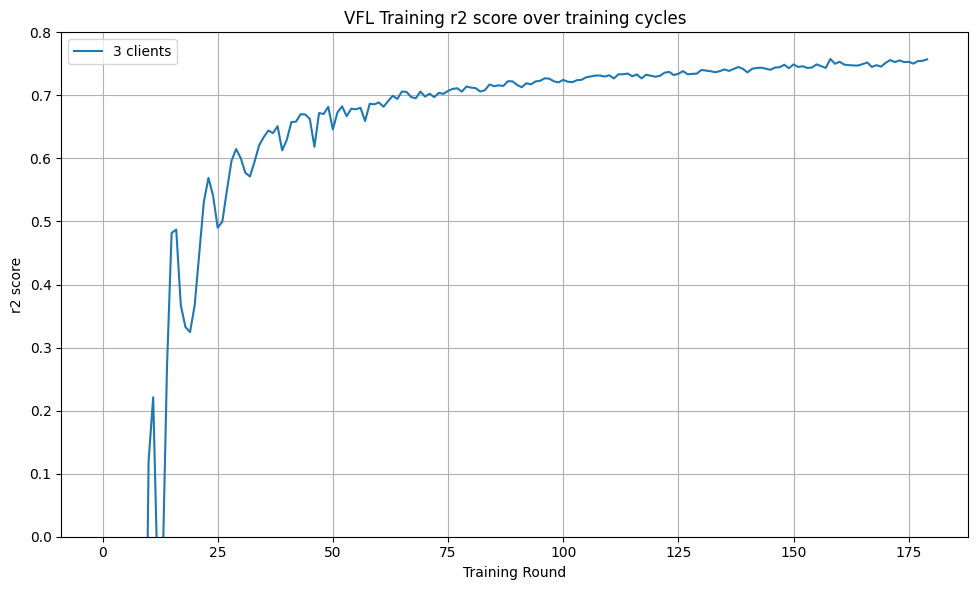

Elapsed time: 237.04497647285461
Finished with code: done


In [45]:
scenario_no = 1
res = trigger_scenario(scenario_no)
with open(f"output/scenario_{scenario_no}.json", 'w') as f :
    json.dump(res, f, indent=2)

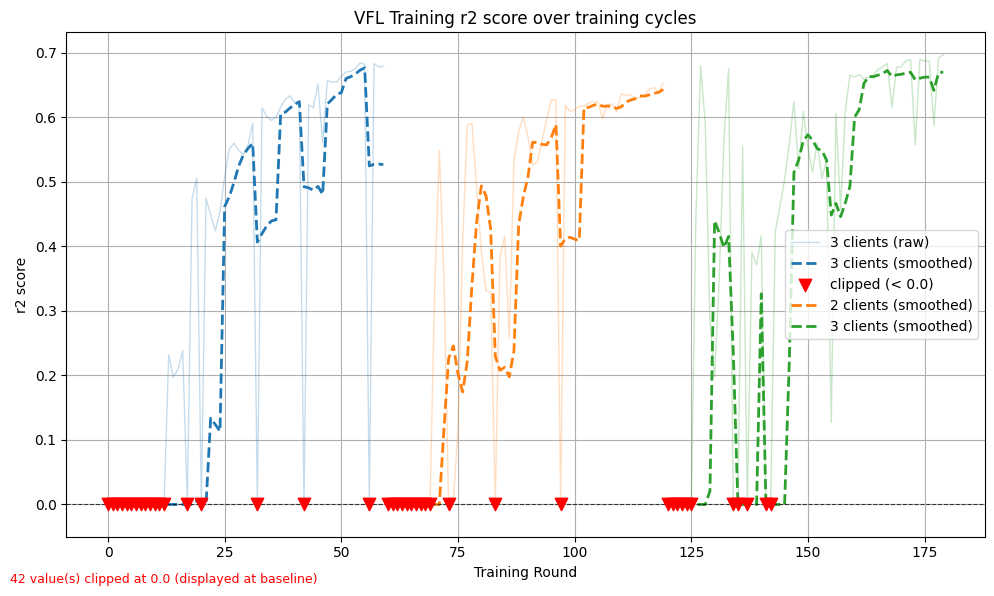

Finished with code: done


In [54]:
# import json

# res = nodes_dict['control']['node'].execute("bash trigger_VFL.sh")


# # parse the request id from json 
# res_dict = json.loads(res[0])
# req_id = res_dict['request_id'] 
# # req_id = res_dict['active_request_id'] 
# # req_status = res_dict['status']
# print(req_id)
# # print(req_status)
# # print(type(res[1]))


# start_time = time.time()
# timeout = 180  # seconds 

# while True:

#     # upload the polling script
#     nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/poll_results.sh", remote_file_path="poll_results.sh")
    
#     # POLL RESULTS 
#     results = nodes_dict['control']['node'].execute(f"bash poll_results.sh {req_id}", quiet=True)
    
#     results_dict = json.loads(results[0])
#     # print(results_dict['metadata'])
#     # print(results_dict['request_id'])
#     # print(results_dict['status'])
#     status = results_dict['status']
#     # print(results_dict['results'])
    
#     accuracies = [k["accuracy"] for k in results_dict['results']]
#     # accuracies = [(a if a >0 else 0) for a in accuracies]  # capping negative values to zero  
    
#     clients = [k["clients"] for k in results_dict['results']]
#     rounds = [k["train_round"] for k in results_dict['results']]

#     if len(clients) <1:
#         print("No results yet, waiting 2 seconds")
#         time.sleep(2)
#         continue
    
#     plot_accuracy(rounds, accuracies, clients)
#     if status!='pending': 
#         break
#     if time.time() - start_time > timeout:
#         print(f"Process timed out. Start time: {start_time}, Duration{time.time() - start_time}, stopping...")
#     time.sleep(2)

# print("Finished with code: " + str(status))


/opt/conda/lib/python3.11/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


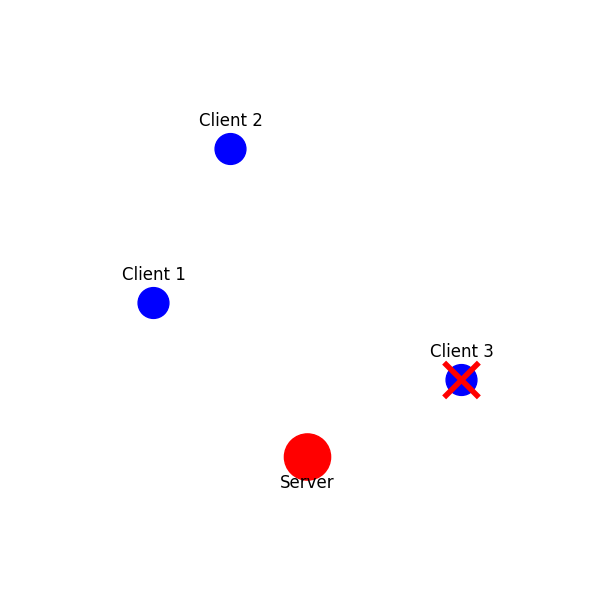

In [5]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch


def get_animation(block_client3=False):

    client_positions = [(1, 3), (2, 5), (5, 2)]
    server_position = (3, 1)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Draw clients and server
    for i, pos in enumerate(client_positions):
        ax.add_patch(plt.Circle(pos, 0.2, color='blue'))
    ax.add_patch(plt.Circle(server_position, 0.3, color='red'))
    
    # Add labels
    for idx, pos in enumerate(client_positions, 1):
        ax.text(pos[0], pos[1]+0.3, f'Client {idx}', ha='center', fontsize=12)
    ax.text(server_position[0], server_position[1]-0.4, 'Server', ha='center', fontsize=12)
    
    blocked_idx = 2  # Index of client to block (Client 3)
    
    # Draw red X for client 3 if blocked
    if block_client3:
        bx, by = client_positions[blocked_idx]
        xsize = 0.2
        ax.plot([bx-xsize, bx+xsize], [by-xsize, by+xsize], color='red', lw=4)
        ax.plot([bx-xsize, bx+xsize], [by+xsize, by-xsize], color='red', lw=4)
    
    # Prepare arrows: one for each client
    arrows = []
    for idx, pos in enumerate(client_positions):
        if block_client3 and idx == blocked_idx:
            arrows.append(None)
            continue
        arrow = FancyArrowPatch(
            posA=pos, posB=pos,
            arrowstyle='->', mutation_scale=25, color='green', lw=3
        )
        ax.add_patch(arrow)
        arrows.append(arrow)
    
    def interpolate(posA, posB, f):
        return (posA[0] + f*(posB[0]-posA[0]), posA[1] + f*(posB[1]-posA[1]))
    
    def animate(frame):
        n_frames = 40
        phase = (frame % n_frames) / n_frames
        for idx, pos in enumerate(client_positions):
            if block_client3 and idx == blocked_idx:
                continue  # No arrows for blocked client
            if phase < 0.5:
                # Send: arrows grow from client towards server
                f = phase * 2
                start = pos
                end = interpolate(pos, server_position, f)
                arrows[idx].set_positions(start, end)
                arrows[idx].set_color('green')
            else:
                # Response: arrows grow from server towards client
                f = (phase - 0.5) * 2
                start = server_position
                end = interpolate(server_position, pos, f)
                arrows[idx].set_positions(start, end)
                arrows[idx].set_color('orange')
        # Only returning visible arrows for blitting
        return [a for a in arrows if a is not None]
    
    ani = animation.FuncAnimation(fig, animate, frames=80, interval=100, blit=True)
    return ani

# ani = get_animation(False)
ani = get_animation(True)
plt.show()


In [6]:
# To stop the animation 
ani.event_source.stop()

In [14]:
accuracies = [k["accuracy"] for k in results_dict['results']]
clients = [k["clients"] for k in results_dict['results']]
rounds = [k["train_round"] for k in results_dict['results']]

In [28]:
accuracies
# clients

[-2.112544298171997,
 -2.110438823699951,
 -2.1101880073547363,
 -2.1117589473724365,
 -2.1052565574645996,
 -2.0895681381225586,
 -2.055121898651123,
 -1.9929835796356201,
 -1.9419820308685303,
 -1.8366219997406006,
 -1.6652071475982666,
 -1.4235599040985107,
 -1.2441644668579102,
 -1.054760456085205,
 -1.0800514221191406,
 -0.8779584169387817,
 -0.4894275665283203,
 -0.09500420093536377,
 0.11060225963592529,
 -1.9149754047393799,
 0.27892786264419556,
 -1.7798709869384766,
 -1.9195497035980225,
 -1.6190829277038574,
 -1.734194278717041,
 0.24040424823760986,
 -1.4100630283355713,
 0.35712724924087524,
 0.3909393548965454,
 0.4009557366371155,
 0.41294240951538086,
 0.44161713123321533,
 0.4640640616416931,
 -0.8486703634262085,
 0.4904049038887024,
 0.48214536905288696,
 0.0835423469543457,
 0.47436201572418213,
 0.4944479465484619,
 0.5376142263412476,
 0.5361632108688354,
 0.5266819000244141,
 0.5300871133804321,
 0.5498026609420776,
 0.21582061052322388,
 0.5357180833816528,
 0.5

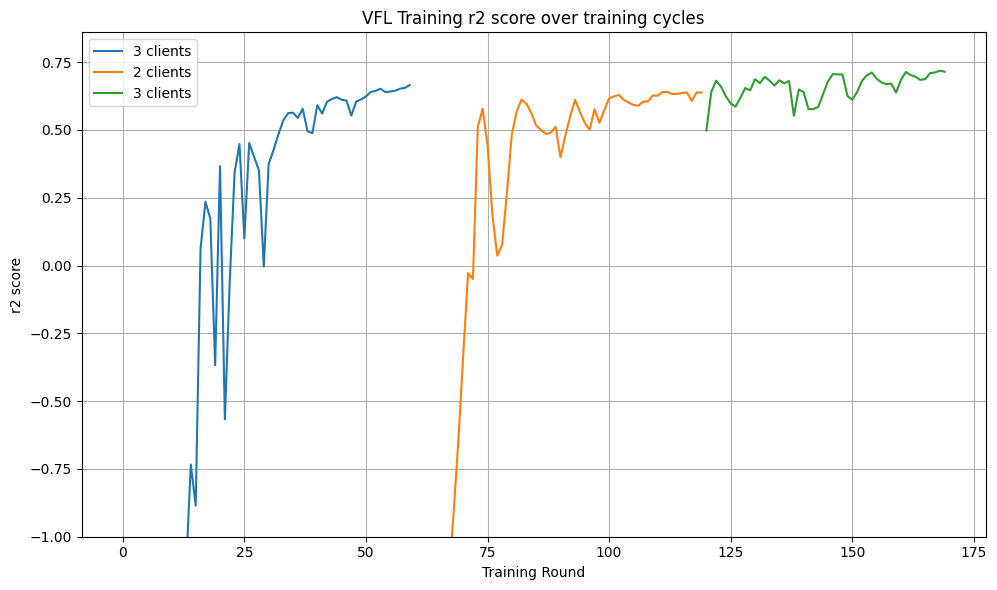

In [20]:
# for testing the incremental plotting
for lim1 in range(10, len(rounds), 10):
    print(lim1)
    plot_accuracy(rounds[:lim1], accuracies[:lim1], clients[:lim1])
    time.sleep(.1)

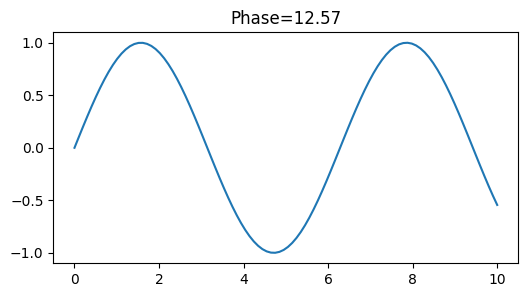

In [17]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import time

x = np.linspace(0, 10, 100)

for phase in np.linspace(0, 4 * np.pi, 60):
    y = np.sin(x + phase)
    plt.figure(figsize=(6,3))
    plt.plot(x, y)
    plt.title(f"Phase={phase:.2f}")
    clear_output(wait=True)
    plt.show()
    time.sleep(0.2)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0{
    "metadata": {
        "policy_reintroduction": 60,
        "policy_removal": 40,
        "total_rounds": 10,
        "training_backtrack": 0
    },
    "request_id": "41c8d594-a441-4ce0-b5bd-2714903e50a6",
    "results": [
        {
            "accuracy": -2.112539052963257,
            "clients": 3,
            "timestamp": "2025-10-15T14:29:23Z",
            "train_round": 0
        },
        {
            "accuracy": -2.1122469902038574,
            "clients": 3,
            "timestamp": "2025-10-15T14:29:23Z",
            "train_round": 1
        },
        {
            "accuracy": -2.11152982711792,
            "clients": 3,
            "timestamp": "2025-10-15T14:29:23Z",
            "train_round": 2
        },
        {
            "accur

In [82]:
%%time
# get API-GATEWAY logs 
nodes_dict['control']['node'].upload_file(local_file_path="../scripts/retrieve_logs.sh", remote_file_path="retrieve_logs.sh")
nodes_dict['control']['node'].execute(f"bash retrieve_logs.sh")

1.7605370374468927e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7605370374469671e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.7605370384475965e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7605370384476235e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.7605370394487271e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7605370394487512e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.7605370404499955e+09 DEBUG	/app/pkg/lib/go-grpc.go:51	returning conn GetGrpcConnection
1.7605370404501572e+09 DEBUG	/ap

('1.7605370374468927e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7605370374469671e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.7605370384475965e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7605370384476235e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.7605370394487271e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7605370394487512e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.7605370404499955e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go

In [41]:
%%time

nodes_dict['control']['node'].upload_file(local_file_path="../scripts/retrieve_logs_policy.sh", remote_file_path="retrieve_logs_policy.sh")
nodes_dict['control']['node'].execute(f"bash retrieve_logs_policy.sh")

1.7603621545040784e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7603621545041149e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.7603621555042522e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7603621555042899e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.760362156504626e+09 WARN	/app/pkg/lib/go-grpc.go:38	could not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"
1.7603621565046625e+09 DEBUG	/app/pkg/lib/go-grpc.go:44	Sleep 1 second
1.7603621575063543e+09 DEBUG	/app/pkg/lib/go-grpc.go:51	returning conn GetGrpcConnection
1.7603621575065098e+09 DEBUG	/app

('1.7603621545040784e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7603621545041149e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.7603621555042522e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7603621555042899e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.760362156504626e+09 \x1bWARN\x1b\t/app/pkg/lib/go-grpc.go:38\tcould not check: rpc error: code = Unavailable desc = connection error: desc = "transport: Error while dialing: dial tcp 127.0.0.1:50051: connect: connection refused"\n1.7603621565046625e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-grpc.go:44\tSleep 1 second\n1.7603621575063543e+09 \x1bDEBUG\x1b\t/app/pkg/lib/go-

In [66]:
%%time
# TODO: read the metrics based on the other script 

nodes_dict['control']['node'].upload_file(local_file_path="../scripts/retrieve_data.sh", remote_file_path="retrieve_data.sh")
nodes_dict['control']['node'].execute(f"bash retrieve_data.sh {2}")


-2.112530469894409
-2.11152982711792
-2.1070847511291504
-2.104970693588257
-2.076059341430664
-2.0829033851623535
-1.9754369258880615
-1.8747782707214355
-1.7195074558258057
-1.4995791912078857
-2.1020915508270264
-2.0844202041625977
-2.051020383834839
-1.9959380626678467
-1.9687869548797607
-2.059821844100952
-1.9815828800201416
-1.9706571102142334
-1.9120151996612549
-1.5650131702423096
-2.1125128269195557
-2.112224578857422
-2.1107711791992188
-2.1057560443878174
-2.105438709259033
-2.07344651222229
-2.0329020023345947
-1.9613666534423828
-1.8438167572021484
-1.6663122177124023
-1.4140856266021729
-1.0831735134124756
-0.6758177280426025
-0.27690041065216064
-0.9888384342193604
-0.03725409507751465
-0.1764448881149292
-0.12805688381195068
0.06951349973678589
0.2743264436721802
0.4248894453048706
0.487127423286438
-0.1479780673980713
-0.0705181360244751
0.4879170060157776
0.48925507068634033
0.4805227518081665
0.4916478395462036
-0.11230874061584473
0.45823103189468384
0.456557452678

('-2.112530469894409\n-2.11152982711792\n-2.1070847511291504\n-2.104970693588257\n-2.076059341430664\n-2.0829033851623535\n-1.9754369258880615\n-1.8747782707214355\n-1.7195074558258057\n-1.4995791912078857\n-2.1020915508270264\n-2.0844202041625977\n-2.051020383834839\n-1.9959380626678467\n-1.9687869548797607\n-2.059821844100952\n-1.9815828800201416\n-1.9706571102142334\n-1.9120151996612549\n-1.5650131702423096\n-2.1125128269195557\n-2.112224578857422\n-2.1107711791992188\n-2.1057560443878174\n-2.105438709259033\n-2.07344651222229\n-2.0329020023345947\n-1.9613666534423828\n-1.8438167572021484\n-1.6663122177124023\n-1.4140856266021729\n-1.0831735134124756\n-0.6758177280426025\n-0.27690041065216064\n-0.9888384342193604\n-0.03725409507751465\n-0.1764448881149292\n-0.12805688381195068\n0.06951349973678589\n0.2743264436721802\n0.4248894453048706\n0.487127423286438\n-0.1479780673980713\n-0.0705181360244751\n0.4879170060157776\n0.48925507068634033\n0.4805227518081665\n0.4916478395462036\n-0.11

In [18]:
for node in nodes:
    print(node)
    ssh_command = node.get_ssh_command().replace(
        "-i /home/fabric/work/fabric_config/slice_key", "-i ~/.ssh/keys/FABRIC-slice_key"
    ).replace(
        "-F /home/fabric/work/fabric_config/ssh_config ", ""
    )
    
    print(ssh_command);

-----------------  --------------------------------------------------------------------------------------------------------------------------------------------
ID                 a0eddf6e-38af-4ade-953e-deb7f505d133
Name               clientthree
Cores              4
RAM                16
Disk               100
Image              default_ubuntu_24
Image Type         qcow2
Host               kans-w1.fabric-testbed.net
Site               KANS
Management IP      2001:400:a100:3060:f816:3eff:fe8e:b4a3
Reservation State  Active
Error Message
SSH Command        ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:400:a100:3060:f816:3eff:fe8e:b4a3
-----------------  --------------------------------------------------------------------------------------------------------------------------------------------
ssh -i ~/.ssh/keys/FABRIC-slice_key ubuntu@2001:400:a100:3060:f816:3eff:fe8e:b4a3
-----------------  ------------------------------------

In [7]:
# Do we need to do it everytime?? I don;t think so but I should test 

slice = fablib.get_slice(name="DYNAMOS-on-FABRIC");
nodes = slice.get_nodes();

for node in nodes:
    ssh_command = node.get_ssh_command().replace(
        "-i /home/fabric/work/fabric_config/slice_key", "-i ~/.ssh/keys/FABRIC-slice_key"
    ).replace(
        "-F /home/fabric/work/fabric_config/ssh_config ", ""
    )
    
    print(ssh_command);

Uploading the node setup...


[<SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572167 mtime=1758572168 ]>,
 <SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572165 mtime=1758572165 ]>,
 <SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572165 mtime=1758572165 ]>,
 <SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572165 mtime=1758572165 ]>,
 <SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572165 mtime=1758572165 ]>,
 <SFTPAttributes: [ size=1222 uid=1000 gid=1000 mode=0o100664 atime=1758572167 mtime=1758572168 ]>]

In [23]:

# Configure DYNAMOS for the FABRIC nodes
# agents_string = ",".join(agents)
# thirdparties_string = ",".join(thirdparties)


# nodes_dict['control']['node'].upload_file(local_file_path="node_scripts/configure_dynamos.sh", remote_file_path="configure_dynamos.sh");
# nodes_dict['control']['node'].execute(f"chmod +x configure_dynamos.sh && ./configure_dynamos.sh {agents_string} {thirdparties_string}");

Adding agents...
- agent 'server'
- agent 'clientone'
- agent 'clienttwo'
- agent 'clientthree'

Adding third parties...


In [24]:
# Optionally override the installation scripts 
# nodes_dict['control']['node'].upload_file(local_file_path="../configuration/dynamos-configuration.sh", remote_file_path="/home/ubuntu/DYNAMOS/configuration/dynamos-configuration.sh")
# nodes_dict['control']['node'].upload_file(local_file_path="../configuration/fill-rabbit-pvc.sh", remote_file_path="/home/ubuntu/DYNAMOS/configuration/fill-rabbit-pvc.sh");


In [37]:
# install DYNAMOS
nodes_dict['control']['node'].execute(f"~/DYNAMOS/configuration/dynamos-configuration.sh")

DYNAMOS configuration v0.1.2
Setting up paths...
definitions_example.json copied over definitions.json to ensure a clean file
Generating RabbitMQ password...
Replacing tokens...
Installing namespaces...
Release "namespaces" does not exist. Installing it now.
NAME: namespaces
LAST DEPLOYED: Wed Nov  5 14:50:23 2025
NAMESPACE: default
STATUS: deployed
REVISION: 1
TEST SUITE: None
Preparing PVC
fill-pvc v0.1.2
pod/temp-pod created
pod/temp-pod-orch created
Waiting for temp-pod to be Running...
pod/temp-pod condition met
pod/temp-pod-orch condition met
pod "temp-pod" deleted
pod "temp-pod-orch" deleted
Installing Prometheus...
"prometheus-community" already exists with the same configuration, skipping
Hang tight while we grab the latest from your chart repositories...
...Successfully got an update from the "prometheus-community" chart repository
Update Complete. ⎈Happy Helming!⎈
Release "prometheus" does not exist. Installing it now.
NAME: prometheus
LAST DEPLOYED: Wed Nov  5 14:51:16 2025

('DYNAMOS configuration v0.1.2\nSetting up paths...\ndefinitions_example.json copied over definitions.json to ensure a clean file\nGenerating RabbitMQ password...\nReplacing tokens...\nInstalling namespaces...\nRelease "namespaces" does not exist. Installing it now.\nNAME: namespaces\nLAST DEPLOYED: Wed Nov  5 14:50:23 2025\nNAMESPACE: default\nSTATUS: deployed\nREVISION: 1\nTEST SUITE: None\nPreparing PVC\nfill-pvc v0.1.2\npod/temp-pod created\npod/temp-pod-orch created\nWaiting for temp-pod to be Running...\npod/temp-pod condition met\npod/temp-pod-orch condition met\npod "temp-pod" deleted\npod "temp-pod-orch" deleted\nInstalling Prometheus...\n"prometheus-community" already exists with the same configuration, skipping\nHang tight while we grab the latest from your chart repositories...\n...Successfully got an update from the "prometheus-community" chart repository\nUpdate Complete. ⎈Happy Helming!⎈\nRelease "prometheus" does not exist. Installing it now.\nNAME: prometheus\nLAST DEP

In [6]:
# Optional to clean up: uninstall DYNAMOS

command = "helm uninstall agents api-gateway core orchestrator namespaces prometheus thirdparties"
nodes_dict['control']['node'].execute(command)

# Uninstall client and server namespaces (sometimes is needed)
command = "kubectl delete namespace clientone clienttwo clientthree server"
nodes_dict['control']['node'].execute(command)

Error: uninstall: Release not loaded: agents: release: not found
Error from server (NotFound): namespaces "clientone" not found
Error from server (NotFound): namespaces "clienttwo" not found
Error from server (NotFound): namespaces "clientthree" not found
Error from server (NotFound): namespaces "server" not found


('',
 'Error from server (NotFound): namespaces "clientone" not found\nError from server (NotFound): namespaces "clienttwo" not found\nError from server (NotFound): namespaces "clientthree" not found\nError from server (NotFound): namespaces "server" not found\n')

In [ ]:
# Optional delete etcd PVCs 
# nodes_dict['control']['node'].execute("kubectl get pvc --all-namespaces")

# nodes_dict['control']['node'].execute("kubectl delete pvc etcd-data-etcd-0 -n core")
# nodes_dict['control']['node'].execute("kubectl delete pvc etcd-data-etcd-1 -n core")
# nodes_dict['control']['node'].execute("kubectl delete pvc etcd-data-etcd-2 -n core")


# nodes_dict['control']['node'].execute("kubectl get pvc --all-namespaces")